# Indoor Air Quality Prediction using LightGBM

This notebook implements a LightGBM model to predict Air Quality based on sensor data from `IAQ Baqubah Teaching Hospital .csv`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
file_path = "IAQ Baqubah Teaching Hospital .csv"
df = pd.read_csv(file_path)

# Display basic info
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523524 entries, 0 to 523523
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CO2          523524 non-null  float64
 1   TVOC         523524 non-null  float64
 2   PM10         523524 non-null  float64
 3   PM2.5        523524 non-null  float64
 4   eCO2         203159 non-null  float64
 5   CO           523524 non-null  float64
 6   Air Quality  523524 non-null  float64
 7   LDR          523524 non-null  float64
 8   O3           523524 non-null  float64
 9   Temp         523524 non-null  float64
 10  Hum          523524 non-null  float64
 11  ts           523524 non-null  object 
dtypes: float64(11), object(1)
memory usage: 47.9+ MB
None


,CO2,TVOC,PM10,PM2.5,eCO2,CO,Air Quality,LDR,O3,Temp,Hum,ts
0,425.000000,4.0,5.190,0.320000,588.0,357.0,42.000000,962.0,522.000000,26.300000,41.700000,5/22/2024 12:13
1,419.500000,26.5,5.240,0.260000,590.0,360.5,41.500000,962.0,521.500000,26.200000,41.650000,5/22/2024 12:14
2,420.666667,19.0,5.760,0.266667,556.0,360.0,41.333333,962.0,523.666667,26.133333,41.666667,5/22/2024 12:15
3,424.000000,15.5,5.765,0.292500,536.0,360.5,40.500000,962.0,524.750000,26.100000,41.650000,5/22/2024 12:16
4,419.200000,22.2,6.946,0.342000,666.5,357.2,40.400000,961.8,526.200000,25.920000,41.980000,5/22/2024 12:50


## 2. Data Preprocessing

In [3]:
# Convert Timestamp
df['ts'] = pd.to_datetime(df['ts'])

# Check for missing values
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
CO2                 0
TVOC                0
PM10                0
PM2.5               0
eCO2           320365
CO                  0
Air Quality         0
LDR                 0
O3                  0
Temp                0
Hum                 0
ts                  0
dtype: int64


In [4]:
# Handling eCO2 missing values
# Strategy: Check correlation with CO2. If high (>0.9), drop. Else, interpolate.

if 'eCO2' in df.columns and 'CO2' in df.columns:
    corr = df[['CO2', 'eCO2']].corr().iloc[0,1]
    print(f"Correlation between CO2 and eCO2: {corr}")
    
    if corr > 0.9:
        print("High correlation detected. Dropping eCO2 column to avoid multicollinearity and missing value issues.")
        df = df.drop(columns=['eCO2'])
    else:
        print("Correlation is acceptable. Imputing missing eCO2 values using interpolation.")
        df['eCO2'] = df['eCO2'].interpolate(method='linear').ffill().bfill()
else:
    print("eCO2 or CO2 column not found.")

# Handle any other remaining missing values with forward fill (time series data)
df = df.ffill().bfill()

print("Missing values after handling:")
print(df.isnull().sum())

Correlation between CO2 and eCO2: 0.02695783161482469
Correlation is acceptable. Imputing missing eCO2 values using interpolation.
Missing values after handling:
CO2            0
TVOC           0
PM10           0
PM2.5          0
eCO2           0
CO             0
Air Quality    0
LDR            0
O3             0
Temp           0
Hum            0
ts             0
dtype: int64


## 3. Feature Selection

In [5]:
# Define features and target
# Based on dataset: CO2, TVOC, PM10, PM2.5, CO, O3, Temp, Hum, LDR

features = ['CO2', 'TVOC', 'PM10', 'Air Quality', 'CO', 'O3', 'Temp', 'Hum', 'LDR']

# Add eCO2 if it wasn't dropped
if 'eCO2' in df.columns:
    features.append('eCO2')

target = 'PM2.5'

X = df[features]
y = df[target]

print(f"Features: {features}")
print(f"Target: {target}")

Features: ['CO2', 'TVOC', 'PM10', 'Air Quality', 'CO', 'O3', 'Temp', 'Hum', 'LDR', 'eCO2']
Target: PM2.5


## 4. Model Training (LightGBM)

In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize LightGBM Regressor
model = lgb.LGBMRegressor(objective='regression', n_estimators=100, learning_rate=0.1, max_depth=5)

# Train model
model.fit(X_train, y_train)

print("Model training complete.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057630 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2549
[LightGBM] [Info] Number of data points in the train set: 418819, number of used features: 10
[LightGBM] [Info] Start training from score 102.411456
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

## 5. Evaluation

Root Mean Squared Error (RMSE): 13.75634126799002
R-squared (R2): 0.9310037445177246


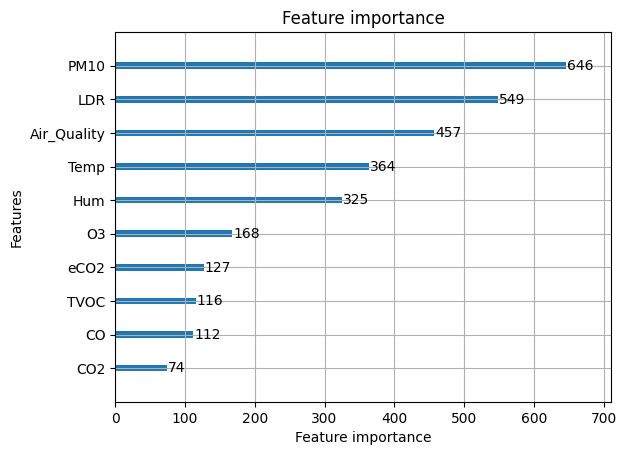

In [7]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

# Feature Importance
lgb.plot_importance(model)
plt.show()

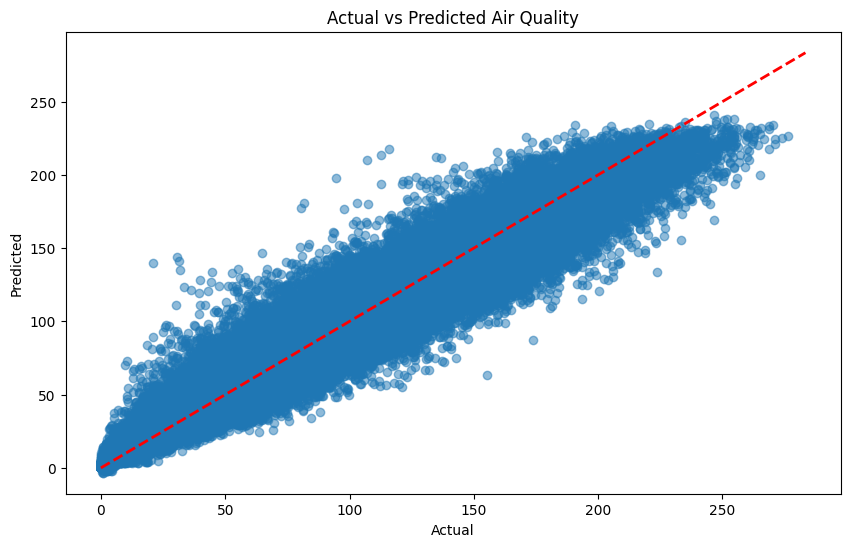

In [ ]:
# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted PM2.5')
plt.show()

In [9]:
# Standardized Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Performance Metrics:')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R2:   {r2:.4f}')

Performance Metrics:
RMSE: 13.7563
MAE:  9.9320
R2:   0.9310
